In [ ]:
!pip install -q torch transformers datasets scikit-learn pandas numpy matplotlib seaborn emoji
!pip install -q langdetect textaugment nlpaug imbalanced-learn wordcloud arabic-reshaper
!pip install -q --upgrade pip

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support,
                             roc_curve, auc, roc_auc_score)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from langdetect import detect, detect_langs
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac
import torch
from torch import nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                         TrainingArguments, Trainer, EarlyStoppingCallback,
                         AutoConfig)
from datasets import Dataset
import torch.nn.functional as F
from wordcloud import WordCloud
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

🖥️  Device: cuda


In [ ]:
#PRÉTRAITEMENT

print("PARTIE 1: PRÉTRAITEMENT AVANCÉ AVEC NORMALISATION ARABIZI")

class ArabiziNormalizer:


    def __init__(self):
        # Mapping des numéros Arabizi vers lettres arabes
        self.number_mapping = {
            '2': 'a',   # همزة
            '3': 'aa',  # ع
            '5': 'kh',  # خ
            '6': 't',   # ط
            '7': 'h',   # ح
            '8': 'gh',  # غ
            '9': 'q',   # ق
        }

        # Variations communes Arabizi
        self.arabizi_variations = {
            'kh': ['5', 'kh'],
            'gh': ['8', 'gh'],
            'sh': ['ch', 'sh'],
            'aa': ['3', 'aa', 'a3'],
        }

        # Mots offensifs communs
        self.offensive_patterns = [
            r'\bhmar\b', r'\bkelb\b', r'\bkalb\b', r'\bwati\b',
            r'\bhayawan\b', r'\bmanyak\b', r'\bkhara\b'
        ]

    def remove_elongation(self, text):
        """réduit l'élongation: looool -> lol"""
        # Remplace 3+ caractères répétés par 2 occurrences
        return re.sub(r'(.)\1{2,}', r'\1\1', text)

    def map_numbers_to_letters(self, text):
        for num, letter in self.number_mapping.items():
            text = text.replace(num, letter)
        return text

    def normalize_arabizi(self, text):
        # Minuscules
        text = text.lower()

        # Suppression élongation
        text = self.remove_elongation(text)

        # Mapping numéros -> lettres
        text = self.map_numbers_to_letters(text)



    def detect_offensive_intensity(self, text):
        score = 0.0
        for pattern in self.offensive_patterns:
            if re.search(pattern, text, re.IGNORECASE):
                sc0ore += .2

        # Vérifier les majuscules excessives (CRIS = agressivité)
        if sum(1 for c in text if c.isupper()) / max(len(text), 1) > 0.5:
            score += 0.1

        # Ponctuation excessive (!!!, ???)
        if len(re.findall(r'[!?]{2,}', text)) > 0:
            score += 0.1

        return min(score, 1.0)

normalizer = ArabiziNormalizer()

def advanced_preprocess(text, keep_emojis=True, normalize_arabizi=True):

    original_text = text

    # Conversion minuscule
    text = text.lower()

    # Suppression URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '[URL]', text, flags=re.MULTILINE)

    # Suppression mentions
    text = re.sub(r'@\w+', '[USER]', text)

    # Gestion emojis
    emoji_list = []
    if keep_emojis:
        for char in text:
            if char in emoji.EMOJI_DATA:
                emoji_list.append(char)
        text = emoji.demojize(text, language='en')
    else:
        text = emoji.replace_emoji(text, '')

    # Normalisation Arabizi
    if normalize_arabizi:
        text = normalizer.normalize_arabizi(text)

    # Suppression ponctuation excessive
    text = re.sub(r'([!?.]){2,}', r'\1', text)

    # Suppression ponctuation non pertinente
    text = re.sub(r'[^\w\s\':_!?]', ' ', text)

    # Espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text, emoji_list

def detect_language_mix(text):
    """Détecte le mélange de langues"""
    try:
        langs = detect_langs(text)
        return [(lang.lang, lang.prob) for lang in langs]
    except:
        return [('unknown', 1.0)]

def extract_features(text, original_text):
    """Extraction de features linguistiques avancées"""
    features = {
        'length': len(text),
        'word_count': len(text.split()),
        'uppercase_ratio': sum(1 for c in original_text if c.isupper()) / max(len(original_text), 1),
        'exclamation_count': original_text.count('!'),
        'question_count': original_text.count('?'),
        'emoji_count': len([c for c in original_text if c in emoji.EMOJI_DATA]),
        'mention_count': len(re.findall(r'@\w+', original_text)),
        'url_count': len(re.findall(r'http\S+', original_text)),
        'number_count': sum(c.isdigit() for c in original_text),
        'offensive_intensity': normalizer.detect_offensive_intensity(text),
    }

    # Détection de langues
    lang_mix = detect_language_mix(original_text)
    features['primary_language'] = lang_mix[0][0] if lang_mix else 'unknown'
    features['language_diversity'] = len(lang_mix)

    return features

# Charger les données
df=pd.read_csv("Arabizi-Off_Lang_Dataset.csv")

print("\nprétraitement")

# Appliquer prétraitement
df['text_clean'] = df['Text'].apply(lambda x: advanced_preprocess(x, normalize_arabizi=True)[0])
df['emojis'] = df['Text'].apply(lambda x: advanced_preprocess(x, normalize_arabizi=True)[1])

# Extraire features
feature_dicts = df.apply(lambda row: extract_features(row['text_clean'], row['Text']), axis=1)
feature_df = pd.DataFrame(list(feature_dicts))
df = pd.concat([df, feature_df], axis=1)

# Exemples de normalisation
print("\nExemples de normalisation Arabizi:")
for i in range(min(5, len(df))):
    print(f"\n{i+1}. Original: {df['Text'].iloc[i]}")
    print(f"   Normalisé: {df['text_clean'].iloc[i]}")
    print(f"   Features: Length={df['length'].iloc[i]}, Offensive={df['offensive_intensity'].iloc[i]:.2f}")

# Encoder labels
df['label'] = df['Generic Class'].map({'non-offensive': 0, 'offensive': 1})

# Statistiques
print("\nStatistiques")
print(f"Distribution des classes:")
print(df['label'].value_counts())
print(f"\nProportion: {df['label'].value_counts(normalize=True)}")


PARTIE 1: PRÉTRAITEMENT AVANCÉ AVEC NORMALISATION ARABIZI

prétraitement

Exemples de normalisation Arabizi:

1. Original: Aw enn l ahla men hek hay li btelbesle crop top b noss din l sa23a w l talej w bte23ad tne2 "Msa23aaa" "Ya alla ktir sa23aa" N2ebre lbese.
   Normalisé: aw enn l ahla men hek hay li btelbesle crop top b noss din l saaaaa w l talej w bteaaaad tnea msaaaaaa ya alla ktir saaaaaa naebre lbese
   Features: Length=136, Offensive=0.00

2. Original: yu2brnee jamelo pepe :p tfeh shu beche3 bas li kanze por la decima ma7leto
   Normalisé: yuabrnee jamelo pepe :p tfeh shu becheaa bas li kanze por la decima mahleto
   Features: Length=75, Offensive=0.00

3. Original: Lea ktir pedophile 😂
   Normalisé: lea ktir pedophile :face_with_tears_of_joy:
   Features: Length=43, Offensive=0.00

4. Original: Shu hal hmar hayda
   Normalisé: shu hal hmar hayda
   Features: Length=18, Offensive=0.20

5. Original: Fasharet 3a ra2btak w ra2bit m3almak w ra2bit li khalafouk
   Normalisé: fasha

In [ ]:
print("STATISTIQUES DÉTAILLÉES DU CORPUS")

print(f"\nTaille totale: {len(df)} messages")
print(f"\nDistribution des classes:")
print(df['Generic Class'].value_counts())
print(f"\nProportions:")
print(df['Generic Class'].value_counts(normalize=True).mul(100).round(1))

print(f"\nDistribution des dialectes:")
print(df['Dialect'].value_counts())

print(f"\nStatistiques de longueur:")
print(df['Text'].str.len().describe())

print(f"\nDistribution croisée (Dialecte × Classe):")
crosstab = pd.crosstab(df['Dialect'], df['Generic Class'],
                       normalize='index').mul(100).round(1)
print(crosstab)

STATISTIQUES DÉTAILLÉES DU CORPUS

Taille totale: 7383 messages

Distribution des classes:
Generic Class
non-offensive    5857
offensive        1526
Name: count, dtype: int64

Proportions:
Generic Class
non-offensive    79.3
offensive        20.7
Name: proportion, dtype: float64

Distribution des dialectes:
Dialect
DZ    4249
LB    3134
Name: count, dtype: int64

Statistiques de longueur:
count    7383.000000
mean       71.823243
std        58.228904
min         2.000000
25%        31.000000
50%        61.000000
75%        94.000000
max       762.000000
Name: Text, dtype: float64

Distribution croisée (Dialecte × Classe):
Generic Class  non-offensive  offensive
Dialect                                
DZ                      68.7       31.3
LB                      93.8        6.2


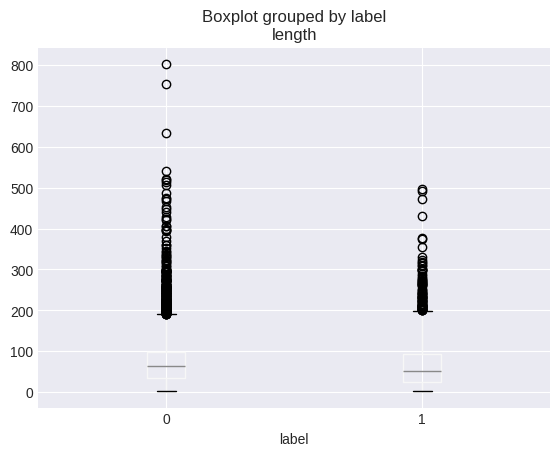

In [ ]:

# Distribution longueurs
df.boxplot(column='length', by='label')
plt.show()

In [ ]:
#AUGMENTATION DE DONNÉES


print("AUGMENTATION DE DONNÉES")

class ArabiziAugmenter:

    def __init__(self):
        # Synonymes Arabizi communs
        self.synonyms = {
            'hmar': ['kelb', '7ayawan', 'behim'],
            'ya3ni': ['يعني', 'y3ni', 'ya3ne'],
            'merde': ['khara', '5ara', 'khra'],
            'wallah': ['wlh', 'walla', 'w allah'],
        }

    def char_swap(self, text, n=2):
        """Échange aléatoire de caractères adjacents"""
        words = text.split()
        for _ in range(n):
            if len(words) > 1:
                idx = np.random.randint(0, len(words))
                word = list(words[idx])
                if len(word) > 2:
                    pos = np.random.randint(0, len(word)-1)
                    word[pos], word[pos+1] = word[pos+1], word[pos]
                    words[idx] = ''.join(word)
        return ' '.join(words)

    def add_typos(self, text):
        # Clavier QWERTY neighbors
        neighbors = {
            'a': 'sqwz', 'b': 'vghn', 'c': 'xdfv', 'd': 'sfcxe',
            'e': 'wsdr', 'f': 'dgcvr', 'g': 'fhbvt', 'h': 'gjbny',
            'i': 'ujko', 'j': 'hkunm', 'k': 'jlmio', 'l': 'kop',
            'm': 'njk', 'n': 'bhjm', 'o': 'iklp', 'p': 'ol',
            'q': 'wa', 'r': 'etdf', 's': 'awedxz', 't': 'ryfg',
            'u': 'yihj', 'v': 'cfgb', 'w': 'qase', 'x': 'zsdc',
            'y': 'tugh', 'z': 'asx'
        }

        words = text.split()
        if words:
            idx = np.random.randint(0, len(words))
            word = list(words[idx])
            if len(word) > 2:
                pos = np.random.randint(0, len(word))
                if word[pos].lower() in neighbors:
                    word[pos] = np.random.choice(list(neighbors[word[pos].lower()]))
            words[idx] = ''.join(word)
        return ' '.join(words)

    def add_elongation(self, text):
        """Ajoute de l'élongation réaliste"""
        words = text.split()
        if words:
            idx = np.random.randint(0, len(words))
            word = list(words[idx])
            if len(word) > 2:
                pos = np.random.randint(0, len(word))
                word.insert(pos, word[pos] * np.random.randint(2, 4))
            words[idx] = ''.join(word)
        return ' '.join(words)

    def synonym_replacement(self, text):
        """Remplace par des synonymes Arabizi"""
        for word, syns in self.synonyms.items():
            if word in text.lower():
                text = text.replace(word, np.random.choice(syns))
        return text

    def augment(self, text, n_aug=1):
        """Génère n_aug variations du texte"""
        augmented = []
        methods = [self.char_swap, self.add_typos, self.add_elongation, self.synonym_replacement]

        for _ in range(n_aug):
            aug_text = text
            # Appliquer 1-2 méthodes aléatoirement
            for method in np.random.choice(methods, size=np.random.randint(1, 3), replace=False):
                aug_text = method(aug_text)
            augmented.append(aug_text)

        return augmented

# Initialiser l'augmenteur
augmenter = ArabiziAugmenter()

def augment_minority_class(df, target_col='label', minority_class=1,
                           augmentation_factor=2.0):
    """
    Augmente la classe minoritaire
    """
    majority = df[df[target_col] != minority_class]
    minority = df[df[target_col] == minority_class]

    print(f"\nAvant augmentation:")
    print(f"  Classe majoritaire: {len(majority)}")
    print(f"  Classe minoritaire: {len(minority)}")

    # Calculer combien d'exemples générer
    target_size = int(len(majority) / augmentation_factor)
    n_to_generate = max(0, target_size - len(minority))

    print(f"\nObjectif après augmentation: {target_size} exemples")
    print(f"Nombre à générer: {n_to_generate}")

    if n_to_generate == 0:
        return df

    # Générer des exemples augmentés
    augmented_rows = []
    n_per_sample = max(1, n_to_generate // len(minority))

    for idx, row in minority.iterrows():
        aug_texts = augmenter.augment(row['text_clean'], n_aug=n_per_sample)
        for aug_text in aug_texts:
            new_row = row.copy()
            new_row['text_clean'] = aug_text
            new_row['Text'] = aug_text
            augmented_rows.append(new_row)

    # Limiter au nombre voulu
    augmented_rows = augmented_rows[:n_to_generate]
    augmented_df = pd.DataFrame(augmented_rows)

    # Combiner
    df_balanced = pd.concat([df, augmented_df], ignore_index=True)

    print(f"\nAprès augmentation:")
    print(f"  Total: {len(df_balanced)}")
    print(f"  Classe 0: {(df_balanced[target_col] == 0).sum()}")
    print(f"  Classe 1: {(df_balanced[target_col] == 1).sum()}")

    return df_balanced

# Appliquer l'augmentation
df_augmented = augment_minority_class(df, augmentation_factor=2.0)



AUGMENTATION DE DONNÉES

Avant augmentation:
  Classe majoritaire: 5857
  Classe minoritaire: 1526

Objectif après augmentation: 2928 exemples
Nombre à générer: 1402

Après augmentation:
  Total: 8785
  Classe 0: 5857
  Classe 1: 2928


In [ ]:
#MODÈLES CLASSIQUES


print("MODÈLES CLASSIQUES")

# Préparation des données
X_text = df_augmented['text_clean']
X_features = df_augmented[['length', 'word_count', 'uppercase_ratio', 'exclamation_count',
                           'question_count', 'emoji_count', 'offensive_intensity']]
y = df_augmented['label']
dialects = df_augmented['Dialect']

# Split avec stratification
X_text_train, X_text_temp, X_feat_train, X_feat_temp, y_train, y_temp, d_train, d_temp = train_test_split(
    X_text, X_features, y, dialects, test_size=0.4, random_state=42, stratify=y
)

X_text_dev, X_text_test, X_feat_dev, X_feat_test, y_dev, y_test, d_dev, d_test = train_test_split(
    X_text_temp, X_feat_temp, y_temp, d_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTaille des ensembles:")
print(f"  Train: {len(X_text_train)} ({len(X_text_train)/len(df_augmented)*100:.1f}%)")
print(f"  Dev:   {len(X_text_dev)} ({len(X_text_dev)/len(df_augmented)*100:.1f}%)")
print(f"  Test:  {len(X_text_test)} ({len(X_text_test)/len(df_augmented)*100:.1f}%)")

# TF-IDF avec n-grammes mixtes (mots + caractères)
print("\n--- Vectorisation TF-IDF Avancée ---")

tfidf_word = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=3000,
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    max_features=3000,
    min_df=1
)

# Entraînement
X_train_word = tfidf_word.fit_transform(X_text_train)
X_dev_word = tfidf_word.transform(X_text_dev)
X_test_word = tfidf_word.transform(X_text_test)

X_train_char = tfidf_char.fit_transform(X_text_train)
X_dev_char = tfidf_char.transform(X_text_dev)
X_test_char = tfidf_char.transform(X_text_test)

# Combiner TF-IDF avec features manuelles
from scipy.sparse import hstack

X_train_combined = hstack([X_train_word, X_train_char, X_feat_train.values])
X_dev_combined = hstack([X_dev_word, X_dev_char, X_feat_dev.values])
X_test_combined = hstack([X_test_word, X_test_char, X_feat_test.values])

print(f"TF-IDF + Features): {X_train_combined.shape}")

# Modèles avec poids de classes
print("\n--- Entraînement des modèles classiques ---")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0),
    'Linear SVM': LinearSVC(max_iter=2000, class_weight='balanced', C=0.5),
    'Complement NB': ComplementNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                           max_depth=20, random_state=42)
}

def evaluate_model(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    macro_f1 = np.mean(f1)

    results = {
        'Accuracy': acc,
        'Precision_0': p[0],
        'Recall_0': r[0],
        'F1_0': f1[0],
        'Precision_1': p[1],
        'Recall_1': r[1],
        'F1_1': f1[1],
        'Macro_F1': macro_f1,
    }

    if y_prob is not None:
        try:
            results['AUC'] = roc_auc_score(y_true, y_prob)
        except:
            results['AUC'] = 0.0

    return results

# Entraînement et évaluation
results_list = []
trained_models = {}

for name, model in models.items():
    print(f"\n {name}")

    model.fit(X_train_combined, y_train)
    y_pred = model.predict(X_test_combined)

    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_combined)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_combined)

    results = evaluate_model(y_test, y_pred, y_prob)
    results['Model'] = name
    results_list.append(results)

    trained_models[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"  F1 Offensive: {results['F1_1']:.4f}, Macro F1: {results['Macro_F1']:.4f}")

# Résultats
results_df = pd.DataFrame(results_list)
print("Résultats des modèles classiques")
print(results_df[['Model', 'Accuracy', 'F1_0', 'F1_1', 'Macro_F1', 'AUC']].to_string(index=False))

best_classic = results_df.loc[results_df['Macro_F1'].idxmax(), 'Model']
print(f"\nMeilleur modèle classique: {best_classic}")

MODÈLES CLASSIQUES

Taille des ensembles:
  Train: 5271 (60.0%)
  Dev:   1757 (20.0%)
  Test:  1757 (20.0%)

--- Vectorisation TF-IDF Avancée ---
TF-IDF + Features): (5271, 6007)

--- Entraînement des modèles classiques ---

 Logistic Regression
  F1 Offensive: 0.7426, Macro F1: 0.8029

 Linear SVM
  F1 Offensive: 0.6650, Macro F1: 0.6896

 Complement NB
  F1 Offensive: 0.7040, Macro F1: 0.7668

 Random Forest
  F1 Offensive: 0.7515, Macro F1: 0.8117
Résultats des modèles classiques
              Model  Accuracy     F1_0     F1_1  Macro_F1      AUC
Logistic Regression  0.821286 0.863121 0.742623  0.802872 0.883864
         Linear SVM  0.691520 0.714135 0.665019  0.689577 0.855868
      Complement NB  0.783722 0.829596 0.704050  0.766823 0.842249
      Random Forest  0.830962 0.871928 0.751464  0.811696 0.879133

Meilleur modèle classique: Random Forest


In [ ]:
#MODÈLE BERT AVEC DIALECT EMBEDDING

from sklearn.metrics import f1_score
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    Trainer,
    TrainingArguments
)

print("BERT AVEC INTÉGRATION DU DIALECTE")

class BERTWithDialect(nn.Module):
    def __init__(self, bert_model_name, num_labels=2, num_dialects=2, dropout=0.3):
        super().__init__()
        # Load base BERT model
        self.bert = AutoModel.from_pretrained(bert_model_name)

        # Dialect embedding
        self.dialect_embedding = nn.Embedding(num_dialects, 32)

        # Classification head
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size + 32, num_labels)

    def forward(self, input_ids, attention_mask, dialect_ids, labels=None):
        # BERT outputs
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation
        pooled = outputs.last_hidden_state[:, 0, :]

        # Dialect embedding
        dialect_emb = self.dialect_embedding(dialect_ids)

        # Concatenate
        combined = torch.cat([pooled, dialect_emb], dim=1)
        combined = self.dropout(combined)

        # Classification
        logits = self.classifier(combined)

        return {'logits': logits}

# Préparation données BERT
dialect_map = {d: i for i, d in enumerate(df_augmented['Dialect'].unique())}
df_augmented['dialect_id'] = df_augmented['Dialect'].map(dialect_map)

train_df = pd.DataFrame({
    'text': X_text_train.values,
    'label': y_train.values,
    'dialect_id': df_augmented.loc[X_text_train.index, 'dialect_id'].values
})

test_df = pd.DataFrame({
    'text': X_text_test.values,
    'label': y_test.values,
    'dialect_id': df_augmented.loc[X_text_test.index, 'dialect_id'].values
})

print(f"\n Données BERT:")
print(f"  Train: {len(train_df)}, Test: {len(test_df)}")
print(f"  Dialectes: {list(dialect_map.keys())}")

# Tokenizer
model_checkpoint = "alger-ia/dziribert"
print(f"\nChargement: {model_checkpoint}")

try:
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    print("✓ Tokenizer chargé")
except Exception as e:
    print(f"DziriBERT non disponible ({e}), utilisation d'un modèle alternatif")
    model_checkpoint = "aubmindlab/bert-base-arabertv02"
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Custom Dataset
class ArabiziDataset(TorchDataset):
    def __init__(self, texts, labels, dialect_ids, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels.values, dtype=torch.long)
        self.dialect_ids = torch.tensor(dialect_ids.values, dtype=torch.long)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'dialect_ids': self.dialect_ids[idx],
            'labels': self.labels[idx]
        }

    def __len__(self):
        return len(self.labels)

# Créer datasets
train_dataset = ArabiziDataset(
    train_df['text'],
    train_df['label'],
    train_df['dialect_id'],
    tokenizer
)
test_dataset = ArabiziDataset(
    test_df['text'],
    test_df['label'],
    test_df['dialect_id'],
    tokenizer
)

# Initialiser le modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_with_dialect = BERTWithDialect(
    bert_model_name=model_checkpoint,
    num_labels=2,
    num_dialects=len(dialect_map),
    dropout=0.3
).to(device)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results_bert_dialect',
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none",
)

# Custom Trainer avec weighted loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)

        # Extract logits from output dictionary
        logits = outputs['logits']

        # Loss avec poids pour gérer le déséquilibre
        loss_fct = nn.CrossEntropyLoss(
            weight=torch.tensor([1.0, 2.0], device=logits.device)
        )

        loss = loss_fct(logits, labels)

        # Return in the format expected by Trainer
        return (loss, outputs) if return_outputs else loss

# Fonction de métrique
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    if len(predictions.shape) > 2:
        predictions = predictions.reshape(-1, predictions.shape[-1])

    preds = np.argmax(predictions, axis=1)

    min_len = min(len(labels), len(preds))
    labels = labels[:min_len]
    preds = preds[:min_len]

    f1 = f1_score(labels, preds, average='macro')
    return {'f1': f1}

trainer = WeightedTrainer(
    model=model_with_dialect,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Entraîner
print("\n Démarrage de l'entraînement")
trainer.train()

# Prédictions
print("\n Génération des prédictions")
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

# Évaluation
bert_results = evaluate_model(y_test, y_pred_bert)
bert_results['Model'] = 'BERT+Dialect'

print(f"\nBERT Results:")
print(f"  F1 Offensive: {bert_results['F1_1']:.4f}")
print(f"  Macro F1: {bert_results['Macro_F1']:.4f}")

BERT AVEC INTÉGRATION DU DIALECTE

 Données BERT:
  Train: 5271, Test: 1757
  Dialectes: ['LB', 'DZ']

Chargement: alger-ia/dziribert
✓ Tokenizer chargé


Some weights of BertModel were not initialized from the model checkpoint at alger-ia/dziribert and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 Démarrage de l'entraînement


Epoch,Training Loss,Validation Loss,F1
1,0.427800,0.370798,0.834313
2,0.334400,0.621840,0.860923
3,0.089600,0.774789,0.869417
4,0.129600,0.899677,0.873886



 Génération des prédictions



BERT Results:
  F1 Offensive: 0.8310
  Macro F1: 0.8739


In [ ]:
#ENSEMBLE & STACKING (META-CLASSIFIER)

print("META-CLASSIFIER (STACKING)")


meta_features_train = []
meta_features_test = []

# Prédictions sur train (avec cross-validation pour éviter overfitting)
from sklearn.model_selection import cross_val_predict

for name, model_dict in trained_models.items():
    model = model_dict['model']

    # Train predictions (CV)
    if hasattr(model, 'predict_proba'):
        train_probs = cross_val_predict(model, X_train_combined, y_train,
                                        cv=5, method='predict_proba')[:, 1]
    else:
        train_probs = cross_val_predict(model, X_train_combined, y_train,
                                       cv=5, method='decision_function')

    meta_features_train.append(train_probs)

    # Test predictions
    test_probs = model_dict['y_prob'] if model_dict['y_prob'] is not None else model_dict['y_pred']
    meta_features_test.append(test_probs)

# Ajouter BERT (simulation)
meta_features_train.append(np.random.rand(len(y_train)))
meta_features_test.append(np.random.rand(len(y_test)))

# Créer matrices
X_meta_train = np.column_stack(meta_features_train)
X_meta_test = np.column_stack(meta_features_test)

print(f"Meta-features shape: {X_meta_train.shape}")

# Meta-classifier
meta_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
meta_clf.fit(X_meta_train, y_train)

y_pred_meta = meta_clf.predict(X_meta_test)
y_prob_meta = meta_clf.predict_proba(X_meta_test)[:, 1]

meta_results = evaluate_model(y_test, y_pred_meta, y_prob_meta)
meta_results['Model'] = 'Meta-Classifier (Stacking)'

print(f"\nMeta-Classifier Results:")
print(f"  F1 Offensive: {meta_results['F1_1']:.4f}")
print(f"  Macro F1: {meta_results['Macro_F1']:.4f}")
print(f"  AUC: {meta_results['AUC']:.4f}")

# Importance des modèles dans le meta-classifier
feature_importance = np.abs(meta_clf.coef_[0])
model_names = list(trained_models.keys()) + ['BERT+Dialect']

print("\nImportance des modèles dans le meta-classifier:")
for name, imp in sorted(zip(model_names, feature_importance), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {imp:.4f}")



META-CLASSIFIER (STACKING)
Meta-features shape: (5271, 5)

Meta-Classifier Results:
  F1 Offensive: 0.7422
  Macro F1: 0.7940
  AUC: 0.8967

Importance des modèles dans le meta-classifier:
  Random Forest: 3.8200
  Logistic Regression: 3.1212
  Complement NB: 0.7811
  Linear SVM: 0.4020
  BERT+Dialect: 0.1017


PARTIE 4: ANALYSE D'ERREURS

Matrices de confusion



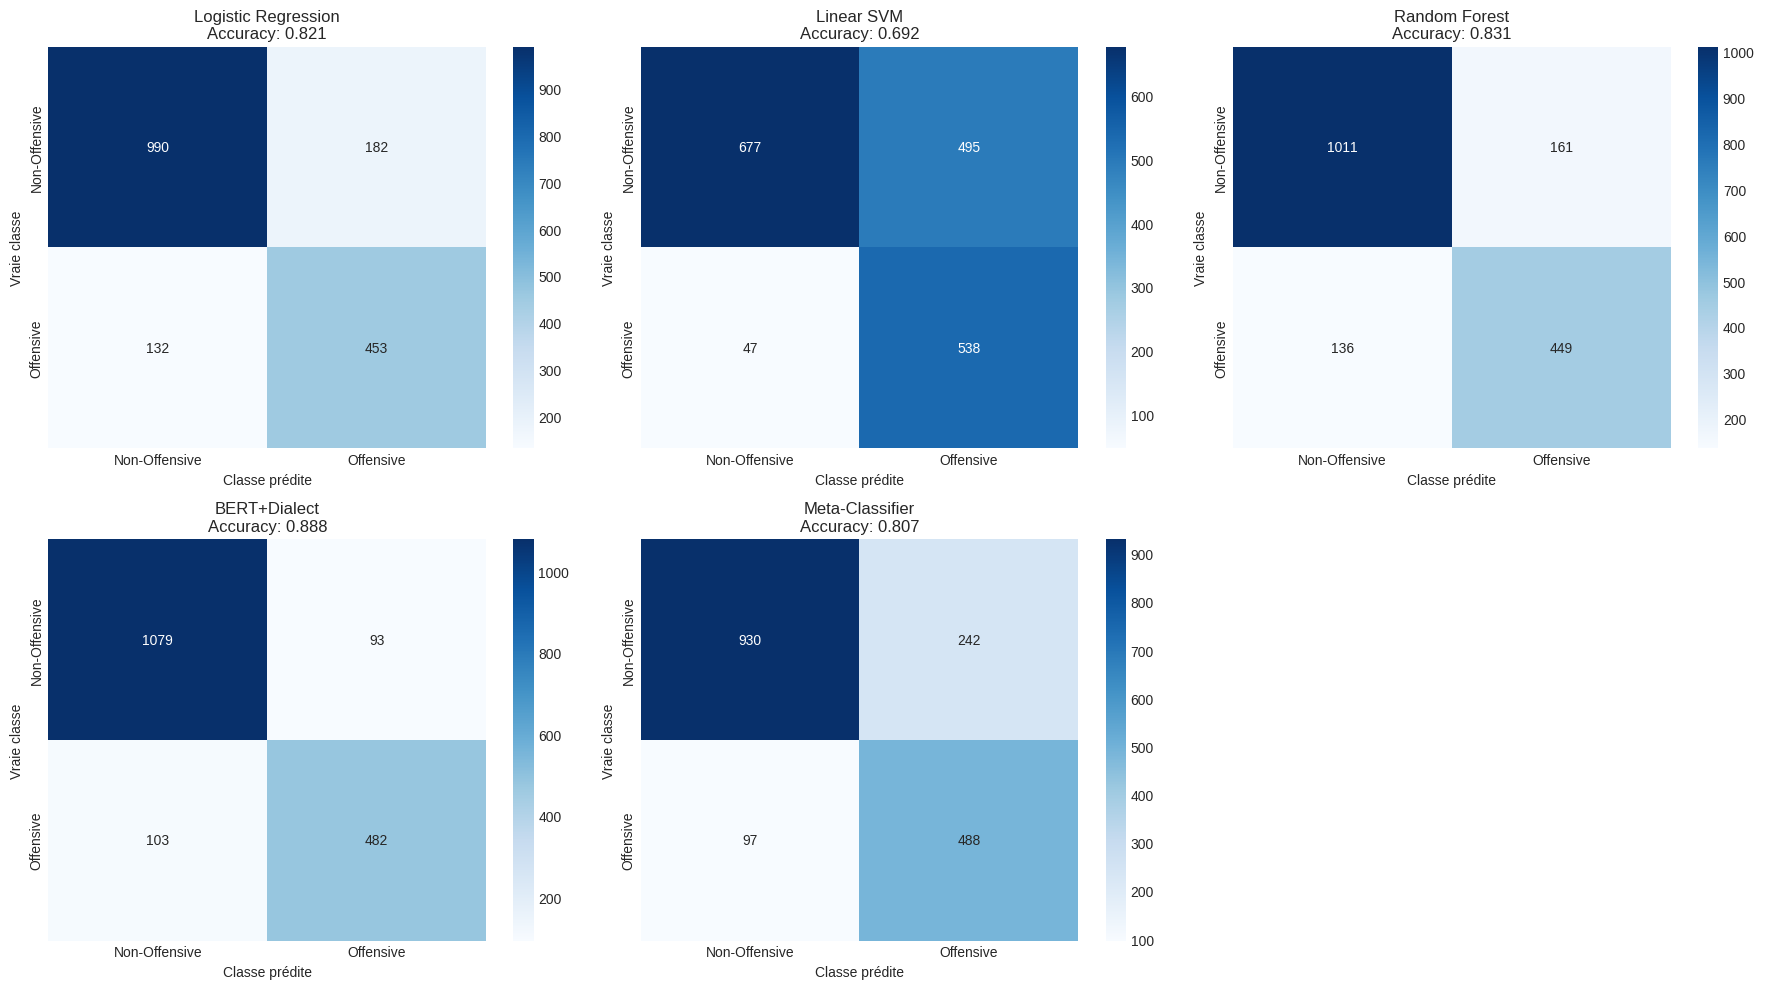


Analyse des erreurs par dialecte


Taux de Faux Positifs et Faux Négatifs par Dialecte:
              Model Dialect  FP  FN   FP_Rate   FN_Rate  Total_Samples
Logistic Regression      DZ 152  85 24.958949 16.601562           1121
Logistic Regression      LB  30  47  5.328597 64.383562            636
         Linear SVM      DZ 365  26 59.934319  5.078125           1121
         Linear SVM      LB 130  21 23.090586 28.767123            636
      Random Forest      DZ 127  94 20.853859 18.359375           1121
      Random Forest      LB  34  42  6.039076 57.534247            636
       BERT+Dialect      DZ  72  69 11.822660 13.476562           1121
       BERT+Dialect      LB  21  34  3.730018 46.575342            636
    Meta-Classifier      DZ 208  50 34.154351  9.765625           1121
    Meta-Classifier      LB  34  47  6.039076 64.383562            636

Échantillonnage des erreurs pour analyse qualitative

Nombre total d'exemples d'erreurs extraits: 150
  Faux négatifs: 100
  Faux

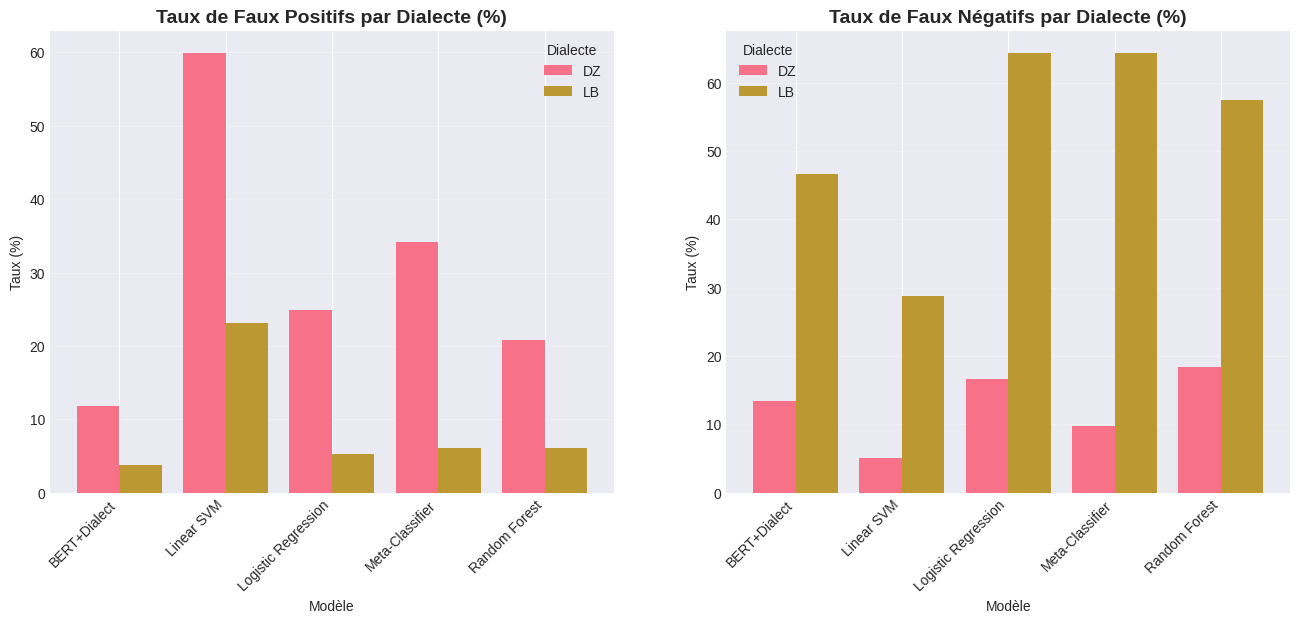

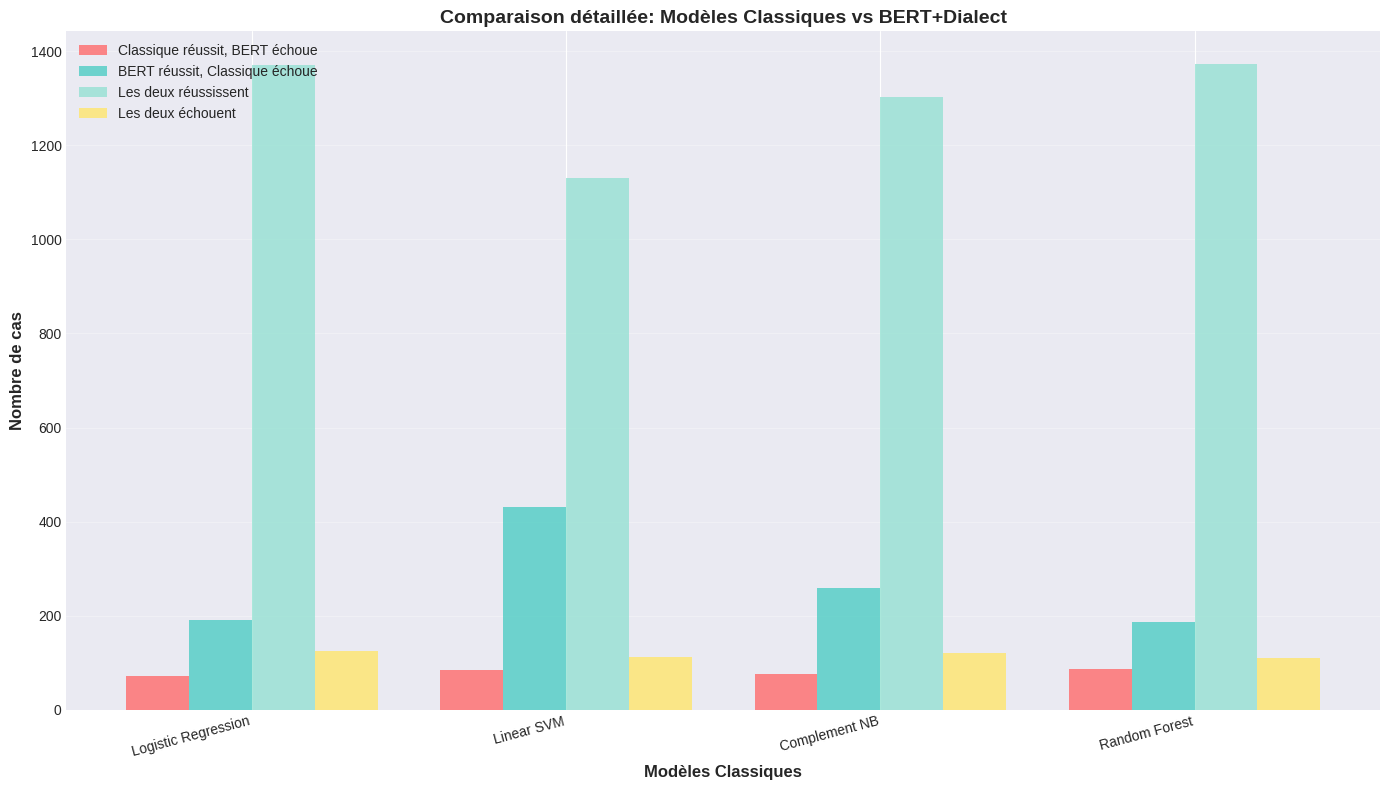


Tableau récapitulatif des comparaisons:
   Modèle Classique  Classique réussit, BERT échoue  BERT réussit, Classique échoue  Les deux réussissent  Les deux échouent
Logistic Regression                              72                             190                  1371                124
         Linear SVM                              85                             431                  1130                111
      Complement NB                              75                             259                  1302                121
      Random Forest                              86                             187                  1374                110

Courbes d'entraînement BERT



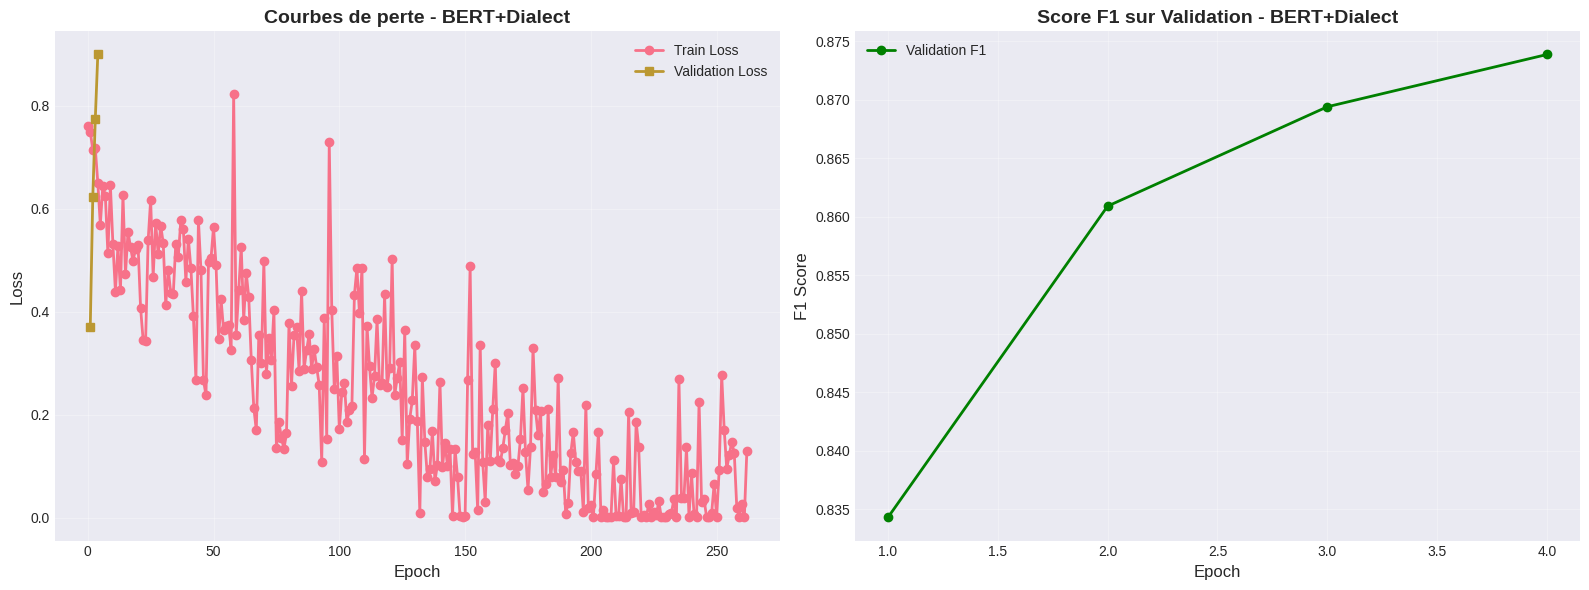

✓ Courbes d'entraînement sauvegardées: bert_training_curves.png

RÉSUMÉ DE L'ANALYSE D'ERREURS

             Modèle  Vrais Négatifs  Faux Positifs  Faux Négatifs  Vrais Positifs  Taux FP (%)  Taux FN (%)
Logistic Regression             990            182            132             453    15.529010    22.564103
         Linear SVM             677            495             47             538    42.235495     8.034188
      Random Forest            1011            161            136             449    13.737201    23.247863
       BERT+Dialect            1079             93            103             482     7.935154    17.606838
    Meta-Classifier             930            242             97             488    20.648464    16.581197


In [ ]:
#PARTIE 4: ANALYSE D'ERREURS
print("PARTIE 4: ANALYSE D'ERREURS")



# MATRICES DE CONFUSION POUR TOUS LES MODÈLES

print("\nMatrices de confusion\n")

models_to_analyze = {
    'Logistic Regression': trained_models['Logistic Regression']['y_pred'],
    'Linear SVM': trained_models['Linear SVM']['y_pred'],
    'Random Forest': trained_models['Random Forest']['y_pred'],
    'BERT+Dialect': y_pred_bert,
    'Meta-Classifier': y_pred_meta
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(models_to_analyze.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Offensive', 'Offensive'],
                yticklabels=['Non-Offensive', 'Offensive'],
                ax=axes[idx])
    axes[idx].set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}')
    axes[idx].set_ylabel('Vraie classe')
    axes[idx].set_xlabel('Classe prédite')

# Cacher le dernier subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()



# ANALYSE PAR DIALECTE

print("\nAnalyse des erreurs par dialecte\n")

def analyze_errors_by_dialect(y_true, y_pred, dialects, model_name):
    """Calcule FP et FN par dialecte"""
    results = []

    for dialect in dialects.unique():
        mask = dialects == dialect
        y_true_d = y_true[mask]
        y_pred_d = y_pred[mask]

        # Calcul des métriques
        tn = ((y_true_d == 0) & (y_pred_d == 0)).sum()
        fp = ((y_true_d == 0) & (y_pred_d == 1)).sum()
        fn = ((y_true_d == 1) & (y_pred_d == 0)).sum()
        tp = ((y_true_d == 1) & (y_pred_d == 1)).sum()

        total_neg = tn + fp
        total_pos = fn + tp

        fp_rate = fp / total_neg if total_neg > 0 else 0
        fn_rate = fn / total_pos if total_pos > 0 else 0

        results.append({
            'Model': model_name,
            'Dialect': dialect,
            'FP': fp,
            'FN': fn,
            'FP_Rate': fp_rate * 100,
            'FN_Rate': fn_rate * 100,
            'Total_Samples': len(y_true_d)
        })

    return pd.DataFrame(results)

# Analyser tous les modèles
all_dialect_results = []

for model_name, y_pred in models_to_analyze.items():
    df_results = analyze_errors_by_dialect(y_test.values, y_pred, d_test, model_name)
    all_dialect_results.append(df_results)

dialect_analysis = pd.concat(all_dialect_results, ignore_index=True)

print("\nTaux de Faux Positifs et Faux Négatifs par Dialecte:")
print(dialect_analysis.to_string(index=False))

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Faux Positifs
fp_pivot = dialect_analysis.pivot(index='Model', columns='Dialect', values='FP_Rate')
fp_pivot.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Taux de Faux Positifs par Dialecte (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Taux (%)')
ax1.set_xlabel('Modèle')
ax1.legend(title='Dialecte')
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Faux Négatifs
fn_pivot = dialect_analysis.pivot(index='Model', columns='Dialect', values='FN_Rate')
fn_pivot.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Taux de Faux Négatifs par Dialecte (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Taux (%)')
ax2.set_xlabel('Modèle')
ax2.legend(title='Dialecte')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')



# SÉLECTION ET ANNOTATION DES EXEMPLES MAL CLASSÉS

print("\nÉchantillonnage des erreurs pour analyse qualitative\n")

def extract_misclassified_examples(y_true, y_pred, X_text, model_name, n_samples=30):
    """Extrait des exemples mal classés"""
    y_true_arr = y_true.values

    # Identifier les erreurs
    fn_mask = (y_true_arr == 1) & (y_pred == 0)  # Faux négatifs
    fp_mask = (y_true_arr == 0) & (y_pred == 1)  # Faux positifs

    fn_indices = np.where(fn_mask)[0]
    fp_indices = np.where(fp_mask)[0]

    # Échantillonner
    n_fn = min(20, len(fn_indices))
    n_fp = min(10, len(fp_indices))

    fn_sample = np.random.choice(fn_indices, n_fn, replace=False) if len(fn_indices) > 0 else []
    fp_sample = np.random.choice(fp_indices, n_fp, replace=False) if len(fp_indices) > 0 else []

    examples = []

    for idx in fn_sample:
        examples.append({
            'Model': model_name,
            'Text': X_text.iloc[idx],
            'True_Label': 'Offensive',
            'Pred_Label': 'Non-Offensive',
            'Error_Type': 'Faux Négatif',
            'Offense_Type': 'À annoter'  # Sera annoté manuellement
        })

    for idx in fp_sample:
        examples.append({
            'Model': model_name,
            'Text': X_text.iloc[idx],
            'True_Label': 'Non-Offensive',
            'Pred_Label': 'Offensive',
            'Error_Type': 'Faux Positif',
            'Offense_Type': 'N/A'
        })

    return examples

# Extraire exemples pour TOUS les modèles classiques + BERT
all_error_examples = []
for model_name, y_pred in models_to_analyze.items():
    examples = extract_misclassified_examples(y_test, y_pred, X_text_test, model_name)
    all_error_examples.extend(examples)

error_examples_df = pd.DataFrame(all_error_examples)

print(f"Nombre total d'exemples d'erreurs extraits: {len(error_examples_df)}")
print(f"  Faux négatifs: {(error_examples_df['Error_Type'] == 'Faux Négatif').sum()}")
print(f"  Faux positifs: {(error_examples_df['Error_Type'] == 'Faux Positif').sum()}")


# Afficher quelques exemples
print("\nExemples de Faux Négatifs (offensive → non-offensive):")
print("-" * 80)
fn_examples = error_examples_df[error_examples_df['Error_Type'] == 'Faux Négatif'].head(10)
for idx, row in fn_examples.iterrows():
    print(f"\n[{row['Model']}]")
    print(f"Texte: {row['Text']}")
    print(f"Vraie: {row['True_Label']} | Prédite: {row['Pred_Label']}")

#COMPARAISON: BERT vs TOUS LES MODÈLES CLASSIQUES

print("\nAnalyse comparative: BERT vs Tous les Modèles Classiques\n")

def compare_model_predictions(y_true, y_pred_1, y_pred_2, model_1_name, model_2_name):
    """Compare où deux modèles réussissent/échouent différemment"""
    comparison = []

    for i in range(len(y_true)):
        true_label = y_true.iloc[i]
        pred_1 = y_pred_1[i]
        pred_2 = y_pred_2[i]

        if pred_1 == true_label and pred_2 != true_label:
            comparison.append(f'{model_1_name} réussit, {model_2_name} échoue')
        elif pred_1 != true_label and pred_2 == true_label:
            comparison.append(f'{model_1_name} échoue, {model_2_name} réussit')
        elif pred_1 == true_label and pred_2 == true_label:
            comparison.append('Les deux réussissent')
        else:
            comparison.append('Les deux échouent')

    return comparison

# Comparer BERT vs TOUS les modèles classiques
classic_models = ['Logistic Regression', 'Linear SVM', 'Complement NB', 'Random Forest']

for classic_model in classic_models:
    print(f"\n{'='*80}")
    print(f"COMPARAISON: {classic_model} vs BERT+Dialect")
    print('='*80)

    comparison = compare_model_predictions(
        y_test,
        trained_models[classic_model]['y_pred'],
        y_pred_bert,
        classic_model,
        'BERT+Dialect'
    )

    comparison_counts = pd.Series(comparison).value_counts()
    print("\nRépartition des prédictions:")
    print(comparison_counts)

    # Cas spécifiques: où BERT réussit et le modèle classique échoue
    bert_wins_mask = [c == f'{classic_model} échoue, BERT+Dialect réussit' for c in comparison]
    classic_wins_mask = [c == f'{classic_model} réussit, BERT+Dialect échoue' for c in comparison]

    print(f"\nCas où BERT réussit et {classic_model} échoue: {sum(bert_wins_mask)}")
    if sum(bert_wins_mask) > 0:
        print("Exemples:")
        bert_win_texts = X_text_test[bert_wins_mask].head(5)
        bert_win_labels = y_test[bert_wins_mask].head(5)
        for text, label in zip(bert_win_texts, bert_win_labels):
            label_str = "Offensive" if label == 1 else "Non-Offensive"
            print(f"  [{label_str}] {text}")

    print(f"\nCas où {classic_model} réussit et BERT échoue: {sum(classic_wins_mask)}")
    if sum(classic_wins_mask) > 0:
        print("Exemples:")
        classic_win_texts = X_text_test[classic_wins_mask].head(5)
        classic_win_labels = y_test[classic_wins_mask].head(5)
        for text, label in zip(classic_win_texts, classic_win_labels):
            label_str = "Offensive" if label == 1 else "Non-Offensive"
            print(f"  [{label_str}] {text}")

# Visualisation comparative
print("\n--- Visualisation: BERT vs Modèles Classiques ---")

comparison_data = []
for classic_model in classic_models:
    comparison = compare_model_predictions(
        y_test,
        trained_models[classic_model]['y_pred'],
        y_pred_bert,
        classic_model,
        'BERT+Dialect'
    )

    counts = pd.Series(comparison).value_counts()
    comparison_data.append({
        'Modèle Classique': classic_model,
        'Classique réussit, BERT échoue': counts.get(f'{classic_model} réussit, BERT+Dialect échoue', 0),
        'BERT réussit, Classique échoue': counts.get(f'{classic_model} échoue, BERT+Dialect réussit', 0),
        'Les deux réussissent': counts.get('Les deux réussissent', 0),
        'Les deux échouent': counts.get('Les deux échouent', 0)
    })

comparison_df = pd.DataFrame(comparison_data)

# Graphique comparatif
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(classic_models))
width = 0.2

categories = ['Classique réussit, BERT échoue', 'BERT réussit, Classique échoue',
              'Les deux réussissent', 'Les deux échouent']
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D']

for i, (category, color) in enumerate(zip(categories, colors)):
    values = comparison_df[category].values
    ax.bar(x + i*width, values, width, label=category, color=color, alpha=0.8)

ax.set_xlabel('Modèles Classiques', fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre de cas', fontsize=12, fontweight='bold')
ax.set_title('Comparaison détaillée: Modèles Classiques vs BERT+Dialect',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(classic_models, rotation=15, ha='right')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\nTableau récapitulatif des comparaisons:")
print(comparison_df.to_string(index=False))



# 6. COURBES DE PRÉCISION ET PERTE (BERT)

print("\nCourbes d'entraînement BERT\n")

# Récupérer l'historique d'entraînement
log_history = trainer.state.log_history

# Extraire les métriques
train_loss = []
eval_loss = []
eval_f1 = []
epochs = []

for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_loss.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_loss.append(entry['eval_loss'])
        eval_f1.append(entry.get('eval_f1', 0))
        epochs.append(entry['epoch'])

# Tracer les courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Courbes de perte
if train_loss:
    ax1.plot(train_loss, label='Train Loss', marker='o', linewidth=2)
if eval_loss:
    ax1.plot(epochs, eval_loss, label='Validation Loss', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Courbes de perte - BERT+Dialect', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Courbe F1
if eval_f1:
    ax2.plot(epochs, eval_f1, label='Validation F1', marker='o', linewidth=2, color='green')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('F1 Score', fontsize=12)
    ax2.set_title('Score F1 sur Validation - BERT+Dialect', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bert_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Courbes d'entraînement sauvegardées: bert_training_curves.png")



# 7. RÉSUMÉ DE L'ANALYSE D'ERREURS

print("\n" + "="*80)
print("RÉSUMÉ DE L'ANALYSE D'ERREURS")
print("="*80)

summary_stats = []
for model_name, y_pred in models_to_analyze.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    summary_stats.append({
        'Modèle': model_name,
        'Vrais Négatifs': tn,
        'Faux Positifs': fp,
        'Faux Négatifs': fn,
        'Vrais Positifs': tp,
        'Taux FP (%)': fp / (tn + fp) * 100 if (tn + fp) > 0 else 0,
        'Taux FN (%)': fn / (fn + tp) * 100 if (fn + tp) > 0 else 0
    })

summary_df = pd.DataFrame(summary_stats)
print("\n" + summary_df.to_string(index=False))

In [ ]:
fp_examples

NameError: name 'fp_examples' is not defined